100.0%
100.0%
100.0%
100.0%


Epoch [0/50] Loss D: 0.4946, Loss G: 0.9917


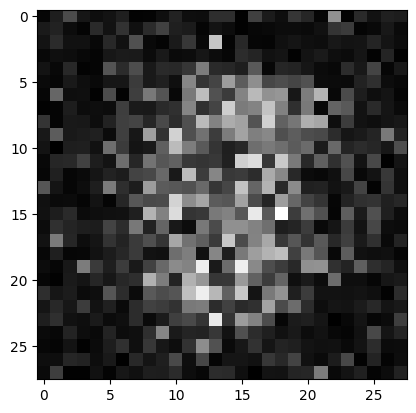

Epoch [10/50] Loss D: 0.6831, Loss G: 0.9890


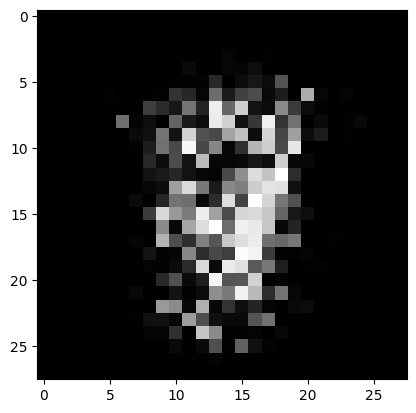

Epoch [20/50] Loss D: 0.2921, Loss G: 2.0743


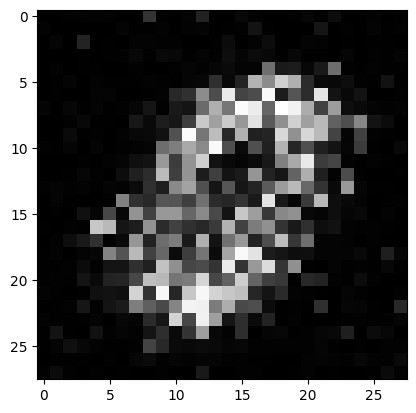

Epoch [30/50] Loss D: 0.2427, Loss G: 2.4770


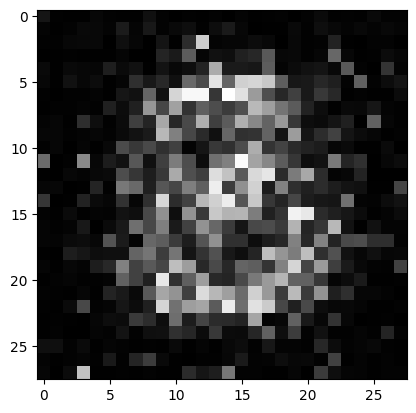

Epoch [40/50] Loss D: 0.4946, Loss G: 1.5981


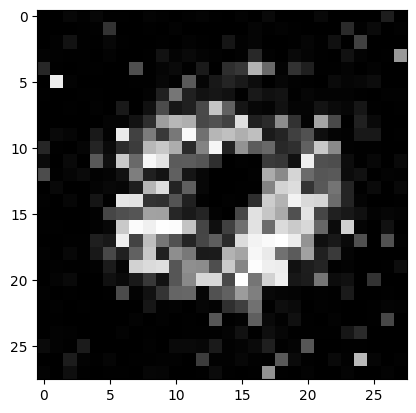

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. Setup & Hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lr = 0.0002
batch_size = 64
z_dim = 100  # Noise vector size
epochs = 50

# 2. Data Preparation (MNIST Digits)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Scales pixels to [-1, 1]
])
dataset = datasets.MNIST(root="dataset/", train=True, transform=transform, download=True)
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 3. The Architectures
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.disc = nn.Sequential(
            nn.Linear(784, 128), nn.LeakyReLU(0.1),
            nn.Linear(128, 1), nn.Sigmoid(), # Output is probability (0 to 1)
        )
    def forward(self, x): return self.disc(x.view(-1, 784))

class Generator(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.gen = nn.Sequential(
            nn.Linear(z_dim, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Tanh(), # Output matches image pixels [-1, 1]
        )
    def forward(self, x): return self.gen(x)

# Initialize models
gen = Generator(z_dim).to(device)
disc = Discriminator().to(device)
opt_gen = optim.Adam(gen.parameters(), lr=lr)
opt_disc = optim.Adam(disc.parameters(), lr=lr)
criterion = nn.BCELoss() # Binary Cross Entropy

# 4. The Training Loop (The Competition)
for epoch in range(epochs):
    for batch_idx, (real, _) in enumerate(loader):
        real = real.to(device)
        batch_curr = real.shape[0]

        ### Train Discriminator: max log(D(real)) + log(1 - D(G(z)))
        noise = torch.randn(batch_curr, z_dim).to(device)
        fake = gen(noise)
        
        disc_real = disc(real).view(-1)
        lossD_real = criterion(disc_real, torch.ones_like(disc_real)) # Label real as 1
        
        disc_fake = disc(fake).view(-1)
        lossD_fake = criterion(disc_fake, torch.zeros_like(disc_fake)) # Label fake as 0
        
        lossD = (lossD_real + lossD_fake) / 2
        disc.zero_grad()
        lossD.backward(retain_graph=True)
        opt_disc.step()

        ### Train Generator: min log(1 - D(G(z))) <-> max log(D(G(z)))
        output = disc(fake).view(-1)
        lossG = criterion(output, torch.ones_like(output)) # Wants Disc to think it's 1
        
        gen.zero_grad()
        lossG.backward()
        opt_gen.step()

    # Visualizing Progress
    if epoch % 10 == 0:
        print(f"Epoch [{epoch}/{epochs}] Loss D: {lossD:.4f}, Loss G: {lossG:.4f}")
        with torch.no_grad():
            sample = gen(torch.randn(1, z_dim).to(device)).view(28,28).cpu()
            plt.imshow(sample, cmap="gray")
            plt.show()